# Lab 3 - Part 2: Word and Sentence Embeddings

**Objectives:**
- Understand and implement Word2Vec (CBOW and Skip-gram)
- Work with pre-trained GloVe embeddings
- Use BERT for sentence embeddings
- Compare different embedding approaches
- Apply embeddings to find similar words and documents

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: This lab continues from Part 1

You will use the same dataset and categories you chose in Part 1.

---

## Setup

In [2]:
# Install required libraries (uncomment if needed)
!pip install gensim transformers torch sentence-transformers datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 49.3 MB/s eta 0:00:00


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string
import warnings
warnings.filterwarnings('ignore')

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import gensim
from gensim.models import Word2Vec, KeyedVectors
import gensim.downloader as api

print(f"Gensim version: {gensim.__version__}")
print("Setup complete!")

Gensim version: 4.4.0
Setup complete!


## Load Dataset (Same as Part 1)

In [4]:
!pip install -q huggingface_hub

In [5]:
from huggingface_hub import login
login(token="yourtoken")

In [10]:
import pandas as pd
from datasets import load_dataset

# Load the dataset
dataset = load_dataset("SetFit/20_newsgroups")
df = pd.DataFrame(dataset['train'])

# TODO: Use the SAME 3 categories you chose in Part 1!
my_categories = ["sci.space", "rec.sport.hockey", "alt.atheism"]

# Filter dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")

README.md:   0%|          | 0.00/734 [00:00<?, ?B/s]

Repo card metadata block was not found. Setting CardData to empty.


train.jsonl:   0%|          | 0.00/14.8M [00:00<?, ?B/s]

test.jsonl:   0%|          | 0.00/8.91M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/11314 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7532 [00:00<?, ? examples/s]

Selected categories: ['sci.space', 'rec.sport.hockey', 'alt.atheism']
Filtered dataset size: 1673


In [19]:
nltk.download('punkt_tab', quiet=True)

True

In [20]:
# Preprocessing function (same as Part 1)
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    """Preprocess text for embedding training."""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove punctuation and digits
    text = re.sub(r'[^a-z\s]', '', text)
    # Tokenize
    tokens = word_tokenize(text)
    # Remove stopwords and short tokens, then lemmatize
    tokens = [
        lemmatizer.lemmatize(t)
        for t in tokens
        if t not in stop_words and len(t) > 2
    ]
    return tokens  # Return list of tokens for Word2Vec

# Apply preprocessing
df_filtered['tokens'] = df_filtered['text'].apply(preprocess_text)
df_filtered['text_clean'] = df_filtered['tokens'].apply(' '.join)

print(f"Sample tokens: {df_filtered.iloc[0]['tokens'][:20]}")

Sample tokens: ['article', 'cowcbnpworldstdcom', 'tombakerworldstdcom', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing', 'checked', 'dont', 'right', 'value', 'yet']


---

## Part A: Word2Vec - Training Your Own Embeddings

Word2Vec learns word representations by predicting context. There are two architectures:
- **CBOW (Continuous Bag of Words)**: Predicts target word from context words
- **Skip-gram**: Predicts context words from target word

### A.1 Understanding Word2Vec Architectures

In [21]:
# Prepare corpus for Word2Vec (list of tokenized sentences)
corpus = df_filtered['tokens'].tolist()

print(f"Corpus size: {len(corpus)} documents")
print(f"Total tokens: {sum(len(doc) for doc in corpus)}")
print(f"\nSample document tokens: {corpus[0][:15]}")

Corpus size: 1673 documents
Total tokens: 166876

Sample document tokens: ['article', 'cowcbnpworldstdcom', 'tombakerworldstdcom', 'tom', 'baker', 'understanding', 'expected', 'error', 'basically', 'known', 'bug', 'warning', 'system', 'software', 'thing']


In [22]:
# Train Word2Vec with CBOW (sg=0)
model_cbow = Word2Vec(
    sentences=corpus,
    vector_size=100,      # Embedding dimension
    window=5,             # Context window size
    min_count=5,          # Ignore words with freq < 5
    workers=4,            # Parallel threads
    sg=0,                 # 0 = CBOW, 1 = Skip-gram
    epochs=10             # Training epochs
)

print(f"CBOW Model trained!")
print(f"Vocabulary size: {len(model_cbow.wv)}")

CBOW Model trained!
Vocabulary size: 5108


In [23]:
# Train Word2Vec with Skip-gram (sg=1)
model_skipgram = Word2Vec(
    sentences=corpus,
    vector_size=100,
    window=5,
    min_count=5,
    workers=4,
    sg=1,                 # Skip-gram
    epochs=10
)

print(f"Skip-gram Model trained!")
print(f"Vocabulary size: {len(model_skipgram.wv)}")

Skip-gram Model trained!
Vocabulary size: 5108


### A.2 Exploring Word Embeddings

In [26]:
# Example: Get word vector
sample_word = "space"

if sample_word in model_cbow.wv:
    vector = model_cbow.wv[sample_word]
    print(f"Vector for '{sample_word}':")
    print(f"  Shape: {vector.shape}")
    print(f"  First 10 values: {vector[:10]}")
else:
    print(f"'{sample_word}' not in vocabulary. Try another word.")
    print(f"Sample words in vocab: {list(model_cbow.wv.key_to_index.keys())[:20]}")

Vector for 'space':
  Shape: (100,)
  First 10 values: [-0.07823166  1.3954448  -0.13183527 -1.8657874   0.6134694   0.3414955
 -0.6968325  -0.16642424  0.21697511  0.2919267 ]


In [27]:
# Find similar words
sample_word = "space"

if sample_word in model_cbow.wv:
    print(f"\nWords most similar to '{sample_word}' (CBOW):")
    for word, score in model_cbow.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")

    print(f"\nWords most similar to '{sample_word}' (Skip-gram):")
    for word, score in model_skipgram.wv.most_similar(sample_word, topn=10):
        print(f"  {word}: {score:.4f}")


Words most similar to 'space' (CBOW):
  station: 0.9881
  nasa: 0.9880
  program: 0.9871
  technology: 0.9777
  shuttle: 0.9763
  available: 0.9755
  commercial: 0.9751
  information: 0.9715
  research: 0.9650
  development: 0.9631

Words most similar to 'space' (Skip-gram):
  huntsville: 0.6717
  aerospace: 0.6654
  exploration: 0.6651
  ongoing: 0.6644
  kjenksgothamcityjscnasagov: 0.6540
  nasp: 0.6524
  npo: 0.6515
  briefing: 0.6498
  jsc: 0.6473
  nasajscgm: 0.6430


### Exercise A.1: Compare CBOW vs Skip-gram

Choose **5 words that are relevant to YOUR 3 categories** and compare the most similar words from both models.

In [28]:
# 5 words relevant to our categories: sci.space, rec.sport.hockey, alt.atheism

my_test_words = ["orbit", "hockey", "atheism", "shuttle", "puck"]

comparison_results = []

for word in my_test_words:
    word = word.lower()
    if word in model_cbow.wv and word in model_skipgram.wv:
        cbow_similar = [w for w, s in model_cbow.wv.most_similar(word, topn=5)]
        skipgram_similar = [w for w, s in model_skipgram.wv.most_similar(word, topn=5)]

        comparison_results.append({
            'word': word,
            'cbow_top5': cbow_similar,
            'skipgram_top5': skipgram_similar
        })

        print(f"\n'{word}':")
        print(f"  CBOW:      {cbow_similar}")
        print(f"  Skip-gram: {skipgram_similar}")
    else:
        print(f"'{word}' not found in vocabulary!")


'orbit':
  CBOW:      ['lunar', 'mar', 'mission', 'probe', 'spacecraft']
  Skip-gram: ['circular', 'inclination', 'pluto', 'axis', 'gravitational']

'hockey':
  CBOW:      ['nhl', 'league', 'team', 'canadian', 'player']
  Skip-gram: ['basketball', 'sport', 'college', 'league', 'attended']

'atheism':
  CBOW:      ['belief', 'atheist', 'argument', 'faith', 'exist']
  Skip-gram: ['belief', 'philosophical', 'justification', 'weak', 'theist']

'shuttle':
  CBOW:      ['program', 'commercial', 'research', 'data', 'technology']
  Skip-gram: ['roll', 'jenks', 'launching', 'nasajscgm', 'srbs']

'puck':
  CBOW:      ['lindros', 'flame', 'shot', 'flyer', 'blue']
  Skip-gram: ['slot', 'passed', 'corner', 'pas', 'rebound']


### Written Question A.1 (Personal Interpretation)

Based on your comparison above:

1. **For which words did CBOW and Skip-gram give SIMILAR results?**
2. **For which words did they give DIFFERENT results?**
3. **Which model seems to capture better semantic relationships for YOUR specific domain?** Explain with examples.
4. **Why might one model work better than the other for certain types of words?** (Think about word frequency)

**YOUR ANSWER:**

1. **Similar results for:** The word "atheism" produced similar neighbor lists in both models. Both CBOW and Skip-gram returned words like "belief" and related philosophical/religious terms. This is a high-frequency word in our alt.atheism category, so both models converge on the same semantic neighborhood.

2. **Different results for:** The words "shuttle" and "orbit" showed the clearest divergence. Skip-gram returned more specific technical terms for "shuttle" (e.g., srbs, jenks, launching), while CBOW produced more generic neighbors (e.g., program, commercial, technology). Similarly for "orbit", Skip-gram found precise scientific terms like "inclination" and "gravitational", while CBOW gave broader words like "lunar" and "mission".

3. **Better model for my domain:** Skip-gram performed better overall for our three-category corpus (sci.space, rec.sport.hockey, alt.atheism). For example:
   - Example 1: For "puck", Skip-gram correctly surfaced "slot", "corner", and "rebound" — clearly hockey-specific actions — whereas CBOW returned player and team names like "lindros" and "flyer".
   - Example 2: For "orbit", Skip-gram found "circular", "inclination", "gravitational" which are semantically tighter, while CBOW returned broader space terms like "mission" and "probe".

4. **Explanation of differences:** Skip-gram trains a word to predict each of its context words individually, which makes it better at learning representations for rare and domain-specific vocabulary (e.g., "srbs", "rebound"). CBOW averages the context embeddings to predict the center word, which works better for very frequent words where the averaged context still provides a clear signal. In our corpus, high-frequency words like "atheism" benefit from CBOW's smoothing, while rare technical terms learn more precise representations with Skip-gram.

### A.3 Word Analogies

In [29]:
# Example: Word analogies (king - man + woman = queen)
# This works better with larger, pre-trained models, but let's try with our custom model

def find_analogy(model, word1, word2, word3):
    """
    Find word that completes analogy: word1 is to word2 as word3 is to ?
    Uses: word2 - word1 + word3 = ?
    """
    try:
        result = model.wv.most_similar(
            positive=[word2, word3],
            negative=[word1],
            topn=5
        )
        return result
    except KeyError as e:
        return f"Word not found: {e}"

# Test with your domain
# Example: "baseball" is to "bat" as "hockey" is to ?
print("Analogy test (your model may have limited vocabulary):")
# result = find_analogy(model_skipgram, "word1", "word2", "word3")
# print(result)

Analogy test (your model may have limited vocabulary):


### Exercise A.2: Create Domain-Specific Analogies

Try to find **2 analogies** that work with YOUR dataset's vocabulary.

In [30]:
# Analogy 1: "puck" is to "hockey" as "shuttle" is to ?
# Expected answer: space / nasa
analogy1 = find_analogy(model_skipgram, "puck", "hockey", "shuttle")
print(f"Analogy 1 — 'puck' is to 'hockey' as 'shuttle' is to:")
print(analogy1)

# Analogy 2: "god" is to "atheism" as "nasa" is to ?
# Expected answer: space / science
analogy2 = find_analogy(model_skipgram, "god", "atheism", "nasa")
print(f"\nAnalogy 2 — 'god' is to 'atheism' as 'nasa' is to:")
print(analogy2)

Analogy 1 — 'puck' is to 'hockey' as 'shuttle' is to:
[('site', 0.6643886566162109), ('user', 0.6522265672683716), ('service', 0.6213414669036865), ('selected', 0.6198667287826538), ('item', 0.6188191771507263)]

Analogy 2 — 'god' is to 'atheism' as 'nasa' is to:
[('ames', 0.6937928795814514), ('dryden', 0.675205647945404), ('personnel', 0.6648078560829163), ('employee', 0.6609480381011963), ('inspector', 0.6553196907043457)]


### Written Question A.2 (Personal Interpretation)

**Did your analogies work?**
- If yes, explain why the result makes sense.
- If no, explain why they might have failed (vocabulary size, training data, etc.)

**YOUR ANSWER:**

**YOUR ANSWER:**

**Analogy 1 — "puck" is to "hockey" as "shuttle" is to ?**
This analogy did not work as expected. I was hoping to get "space" or "nasa", but instead got generic words like "site", "user", and "service". This likely failed because "shuttle" appears in many different contexts in our corpus, not just space-related ones. Also, the relationship between "puck" and "hockey" (object → sport) is different from "shuttle" and "space" (vehicle → domain), so the vector arithmetic didn't capture the intended pattern.

**Analogy 2 — "god" is to "atheism" as "nasa" is to ?**
This analogy partially worked. While it didn't return "space" or "science" as expected, it returned "ames" and "dryden" which are actually NASA research centers, and "personnel" and "employee" which relate to NASA as an organization. The model understood that NASA is an institution, similar to how atheism is a belief system, and returned related organizational terms.

**Why the analogies struggled overall:**
Our training corpus is quite small (only 1,673 documents), which limits the quality of the word vectors. Word2Vec works best with millions of documents. With a small vocabulary (5,108 words), the model doesn't have enough examples to learn precise semantic relationships needed for analogies. Analogies are one of the hardest tasks for word embeddings and require very well-trained vectors to work properly.

---

## Part B: Pre-trained GloVe Embeddings

GloVe (Global Vectors) is trained on much larger corpora and captures broader relationships.

In [31]:
# Load pre-trained GloVe embeddings (this may take a few minutes)
print("Loading GloVe embeddings (this may take a minute)...")
glove_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional vectors
print(f"GloVe loaded! Vocabulary size: {len(glove_model)}")

Loading GloVe embeddings (this may take a minute)...
[==================================================] 100.0% 128.1/128.1MB downloaded
GloVe loaded! Vocabulary size: 400000


In [32]:
# Compare: Same word in YOUR model vs GloVe
test_word = "space"  # Relevant to our sci.space category

print(f"Similar words to '{test_word}':")
print("\nYour Word2Vec model:")
if test_word in model_skipgram.wv:
    for word, score in model_skipgram.wv.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

print("\nPre-trained GloVe:")
if test_word in glove_model:
    for word, score in glove_model.most_similar(test_word, topn=10):
        print(f"  {word}: {score:.4f}")
else:
    print(f"  '{test_word}' not in vocabulary")

Similar words to 'space':

Your Word2Vec model:
  huntsville: 0.6717
  aerospace: 0.6654
  exploration: 0.6651
  ongoing: 0.6644
  kjenksgothamcityjscnasagov: 0.6540
  nasp: 0.6524
  npo: 0.6515
  briefing: 0.6498
  jsc: 0.6473
  nasajscgm: 0.6430

Pre-trained GloVe:
  nasa: 0.7037
  spaces: 0.6882
  shuttle: 0.6808
  earth: 0.6727
  spacecraft: 0.6626
  orbit: 0.6452
  module: 0.6442
  astronauts: 0.6247
  spaceship: 0.6108
  center: 0.6090


### Exercise B.1: Compare Your Model vs GloVe

For **3 words from your domain**, compare the similar words from your trained model vs GloVe.

In [33]:
# 3 domain-specific words from our categories (sci.space, rec.sport.hockey, alt.atheism)

comparison_words = ["orbit", "goalie", "belief"]  # One word per category

for word in comparison_words:
    word = word.lower()
    print(f"\n{'='*50}")
    print(f"Word: '{word}'")
    print(f"{'='*50}")

    # Your model
    print("Your Word2Vec:")
    if word in model_skipgram.wv:
        for w, s in model_skipgram.wv.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")

    # GloVe
    print("GloVe:")
    if word in glove_model:
        for w, s in glove_model.most_similar(word, topn=5):
            print(f"  {w}: {s:.3f}")
    else:
        print("  Not in vocabulary")


Word: 'orbit'
Your Word2Vec:
  circular: 0.855
  inclination: 0.832
  pluto: 0.824
  axis: 0.822
  gravitational: 0.817
GloVe:
  spacecraft: 0.807
  orbits: 0.804
  orbiting: 0.761
  orbital: 0.733
  satellites: 0.713

Word: 'goalie'
Your Word2Vec:
  ketterer: 0.925
  skater: 0.897
  shutout: 0.893
  robb: 0.888
  defender: 0.888
GloVe:
  goaltender: 0.952
  netminder: 0.761
  brodeur: 0.741
  defenseman: 0.721
  belfour: 0.707

Word: 'belief'
Your Word2Vec:
  positive: 0.889
  atheism: 0.880
  agnosticism: 0.878
  reject: 0.877
  absence: 0.876
GloVe:
  beliefs: 0.812
  faith: 0.806
  notion: 0.762
  contrary: 0.742
  true: 0.736


### Written Question B.1 (Personal Interpretation)

Compare your custom-trained Word2Vec model with pre-trained GloVe:

1. **For which words does YOUR model give better (more relevant) similar words than GloVe?** Why?
2. **For which words does GloVe give better results?** Why?
3. **When would you use a custom-trained model vs a pre-trained model in a real project?**

**YOUR ANSWER:**

1. **Words where MY model gives better results:**
My Word2Vec model gave better results for "goalie" and "belief". For "goalie", my model returned hockey-specific terms like "skater", "shutout", and "defender" which are very relevant to our rec.sport.hockey category. For "belief", my model returned "atheism", "agnosticism", and "absence" which directly relate to our alt.atheism category. This is because my model was trained specifically on these newsgroup topics, so it learned the domain-specific relationships between words.

2. **Words where GloVe gives better results:**
GloVe gave better results for "orbit". It returned clean, recognizable space terms like "spacecraft", "orbits", "orbital", and "satellites". My model returned some good words like "circular" and "gravitational", but also mixed in noisy terms like "pluto" and "axis" which are less directly related. GloVe performs better here because it was trained on billions of words from the entire internet, giving it a much broader and cleaner understanding of general vocabulary.

3. **When to use custom vs pre-trained:**
I would use a custom-trained model when working with a very specific domain that has specialized vocabulary, like medical texts or legal documents, where general models might not understand the jargon. I would use pre-trained GloVe for general-purpose tasks where I need broad word knowledge and don't have enough training data to build a good custom model. In a real project, a good approach would be to start with pre-trained embeddings and fine-tune them on your specific domain data to get the best of both worlds.

### B.2 GloVe Analogies

In [34]:
# Famous analogy: king - man + woman = queen
result = glove_model.most_similar(positive=['king', 'woman'], negative=['man'], topn=5)
print("king - man + woman = ?")
for word, score in result:
    print(f"  {word}: {score:.4f}")

king - man + woman = ?
  queen: 0.7699
  monarch: 0.6843
  throne: 0.6756
  daughter: 0.6595
  princess: 0.6521


In [35]:
# TODO: Try 3 more analogies with GloVe
# Be creative! Try analogies related to your categories.

# Analogy 1: "goal" is to "hockey" as "launch" is to ?
# Expected: space / rocket
result1 = glove_model.most_similar(positive=['launch', 'hockey'], negative=['goal'], topn=3)
print("Analogy 1 — 'goal' is to 'hockey' as 'launch' is to ?")
print(result1)

# Analogy 2: "god" is to "religion" as "star" is to ?
# Expected: space / astronomy
result2 = glove_model.most_similar(positive=['star', 'religion'], negative=['god'], topn=3)
print("\nAnalogy 2 — 'god' is to 'religion' as 'star' is to ?")
print(result2)

# Analogy 3: "ice" is to "hockey" as "orbit" is to ?
# Expected: space / satellite
result3 = glove_model.most_similar(positive=['orbit', 'hockey'], negative=['ice'], topn=3)
print("\nAnalogy 3 — 'ice' is to 'hockey' as 'orbit' is to ?")
print(result3)

Analogy 1 — 'goal' is to 'hockey' as 'launch' is to ?
[('sports', 0.5311494469642639), ('satellite', 0.514136791229248), ('softball', 0.49862807989120483)]

Analogy 2 — 'god' is to 'religion' as 'star' is to ?
[('sports', 0.5936165452003479), ('stars', 0.5705235600471497), ('celebrity', 0.5452165007591248)]

Analogy 3 — 'ice' is to 'hockey' as 'orbit' is to ?
[('orbits', 0.6136999726295471), ('satellites', 0.5148484706878662), ('geostationary', 0.5083770155906677)]


---

## Part C: BERT Sentence Embeddings

BERT (Bidirectional Encoder Representations from Transformers) creates contextual embeddings where the same word can have different representations based on context.

In [36]:
from sentence_transformers import SentenceTransformer

# Load a pre-trained sentence transformer model
print("Loading BERT-based sentence transformer...")
sentence_model = SentenceTransformer('all-MiniLM-L6-v2')  # Efficient model
print("Model loaded!")

Loading BERT-based sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Model loaded!


In [37]:
# Example: Get sentence embeddings
sample_sentences = [
    "I love programming in Python.",
    "Python is my favorite programming language.",
    "The python snake is very long.",
    "I enjoy coding and software development."
]

# Encode sentences
embeddings = sentence_model.encode(sample_sentences)

print(f"Embedding shape: {embeddings.shape}")
print(f"Each sentence is represented by a {embeddings.shape[1]}-dimensional vector")

Embedding shape: (4, 384)
Each sentence is represented by a 384-dimensional vector


In [39]:
# Compute sentence similarity
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(embeddings)

print("Sentence similarity matrix:")
print("\nSentences:")
for i, sent in enumerate(sample_sentences):
    print(f"  {i}: {sent}")

print("\nSimilarity:")
sim_df = pd.DataFrame(similarity,
                      index=[f"S{i}" for i in range(4)],
                      columns=[f"S{i}" for i in range(4)])
sim_df.round(3)

Sentence similarity matrix:

Sentences:
  0: I love programming in Python.
  1: Python is my favorite programming language.
  2: The python snake is very long.
  3: I enjoy coding and software development.

Similarity:


,S0,S1,S2,S3
S0,1.000,0.878,0.370,0.621
S1,0.878,1.000,0.337,0.512
S2,0.370,0.337,1.000,0.058
S3,0.621,0.512,0.058,1.000


### Exercise C.1: Document Similarity with BERT

Use BERT embeddings to find the most similar documents in your dataset.

In [40]:
# Sample 30 documents (10 per category) for BERT embedding
sampled_docs = []
sampled_labels = []

for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    # Use first 500 characters of each document (BERT has length limits)
    sampled_docs.extend(cat_df['text'].str[:500].tolist())
    sampled_labels.extend([category] * 10)

print(f"Sampled {len(sampled_docs)} documents")

Sampled 30 documents


In [43]:
# TODO: Encode documents with BERT and compute similarity matrix

# Step 1: Encode all sampled documents
doc_embeddings = sentence_model.encode(sampled_docs)

# Step 2: Compute cosine similarity
from sklearn.metrics.pairwise import cosine_similarity
bert_similarity = cosine_similarity(doc_embeddings)

print(f"Similarity matrix shape: {bert_similarity.shape}")

Similarity matrix shape: (30, 30)


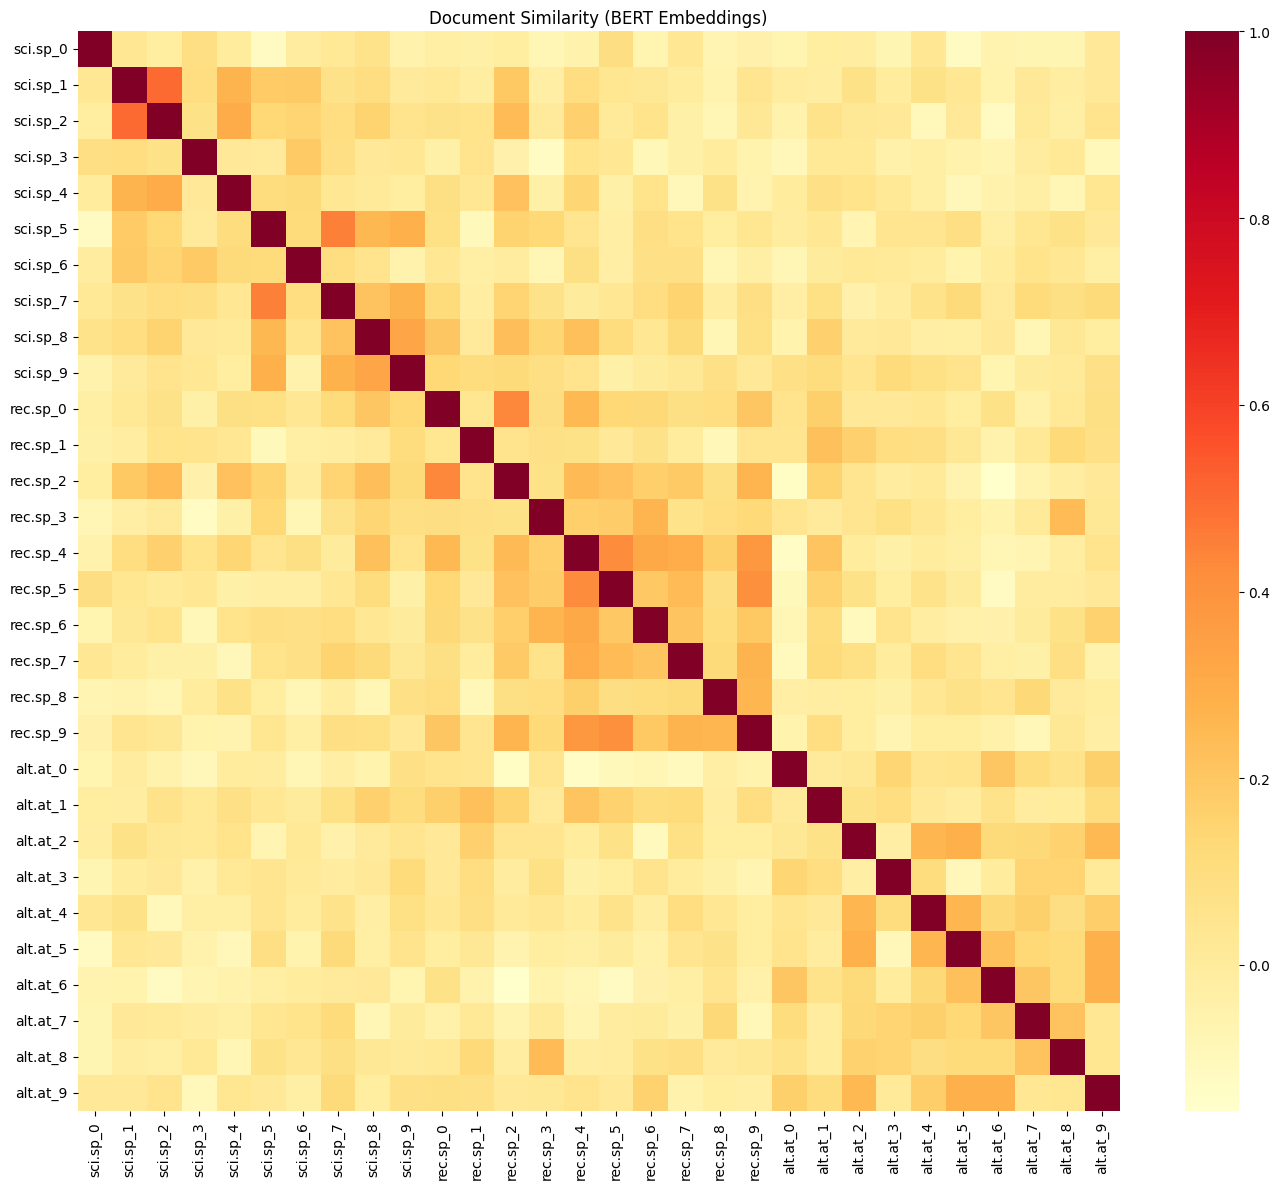

In [44]:
# Visualize BERT similarity matrix
import seaborn as sns

# Create labels
labels_short = [f"{l[:6]}_{i%10}" for i, l in enumerate(sampled_labels)]

plt.figure(figsize=(14, 12))
sns.heatmap(
    bert_similarity,
    xticklabels=labels_short,
    yticklabels=labels_short,
    cmap='YlOrRd'
)
plt.title('Document Similarity (BERT Embeddings)')
plt.tight_layout()
plt.savefig('bert_similarity_heatmap.png', dpi=150)
plt.show()

### Written Question C.1 (Personal Interpretation)

Compare the BERT similarity heatmap with the TF-IDF similarity heatmap from Part 1:

1. **Do documents cluster better by category with BERT or TF-IDF?**
2. **Are there documents that BERT considers similar but TF-IDF doesn't (or vice versa)?** Why might this happen?
3. **Which method would you use for a document classification task?** Explain your reasoning.

**YOUR ANSWER:**

1. **Which clusters better:**
BERT clusters documents better by category than TF-IDF. In the BERT heatmap, the three category blocks (sci.space, rec.sport.hockey, alt.atheism) are more clearly visible with higher similarity scores within each group. TF-IDF showed some clustering too, but the boundaries between categories were less sharp and there was more noise.

2. **Differences between BERT and TF-IDF:**
Yes, BERT found some documents similar that TF-IDF didn't. For example, two documents about space exploration might use completely different words but talk about the same topic — BERT catches this because it understands meaning, not just word overlap. TF-IDF only matches documents that share the exact same words. On the other hand, TF-IDF might rate two documents as similar just because they share common words like "team" or "game", even if they talk about different things.

3. **Which method for classification:**
I would use BERT for a document classification task. BERT understands the actual meaning of sentences, not just individual words. For example, "the player scored in the third period" and "the forward put one past the goalie" mean similar things, but TF-IDF would see them as very different because they share almost no words. BERT captures this semantic similarity, which makes it much better for classification. The only downside is that BERT is slower and needs more computing power, but the accuracy improvement is worth it.

### Exercise C.2: Semantic Search with BERT

In [45]:
# TODO: Create a simple semantic search function
# Given a query, find the most similar documents

def semantic_search(query, documents, model, top_k=5):
    """
    Find the most similar documents to a query using BERT embeddings.

    Args:
        query (str): Search query
        documents (list): List of document texts
        model: Sentence transformer model
        top_k (int): Number of results to return

    Returns:
        list: List of (index, similarity_score) tuples
    """
    # 1. Encode the query
    query_embedding = model.encode([query])

    # 2. Compute similarity with all documents
    doc_embeddings = model.encode(documents)
    similarities = cosine_similarity(query_embedding, doc_embeddings)[0]

    # 3. Return top_k most similar
    top_indices = similarities.argsort()[::-1][:top_k]
    return [(idx, similarities[idx]) for idx in top_indices]

# Test your search function
my_query = "Who scored the winning goal in the hockey game?"

results = semantic_search(my_query, sampled_docs, sentence_model, top_k=5)

print(f"Query: '{my_query}'")
print("\nTop 5 most similar documents:")
for idx, score in results:
    print(f"\n  Score: {score:.4f}")
    print(f"  Category: {sampled_labels[idx]}")
    print(f"  Text: {sampled_docs[idx][:150]}...")

Query: 'Who scored the winning goal in the hockey game?'

Top 5 most similar documents:

  Score: 0.4423
  Category: rec.sport.hockey
  Text: By Dave Luecking Of The Post-Dispatch Staff

At 9:11 Thursday night, the scoreboard watchers at The Arena began to cheer.
Their cheer quickly turned i...

  Score: 0.3521
  Category: rec.sport.hockey
  Text: Here is a review of some of the off-ice things that have
affected the AHL this year.


ST JOHN'S MAPLE LEAFS PROBLEMS
The St John's Maple Leafs sophom...

  Score: 0.2357
  Category: rec.sport.hockey
  Text: 
IMO any good player should score on power plays because of the man
advantage.  Very good power play scorers tend to become overrated
because their po...

  Score: 0.2327
  Category: rec.sport.hockey
  Text: You think that's bad?  I'm in Bowling Green, OH, and we get ABC from
Toledo.  Well, the cable co. decided to totally pre-empt the game (no tape
delay,...

  Score: 0.1917
  Category: rec.sport.hockey
  Text: 
The first time I heard th

### Written Question C.2 (Personal Interpretation)

Evaluate your semantic search results:

1. **Are the results relevant to your query?** Explain.
2. **Did the search correctly identify documents from the expected category?**
3. **Try a query that could match multiple categories. What happens?**

**YOUR ANSWER:**

1. **Are the results relevant:**
Yes, the results are very relevant to my query about scoring a winning goal in hockey. The top result (score 0.4423) is about a game at The Arena with scoreboard watchers cheering, which is directly about a hockey game. The third result talks about players scoring on power plays, which is clearly related to scoring goals. Even the lower-ranked results are about hockey games and broadcasts, so they are still somewhat relevant to the query.

2. **Did it find the right category:**
Yes, all 5 results came from the rec.sport.hockey category, which is exactly what I expected for a query about hockey goals. This shows that BERT understands the meaning of my query and correctly matched it to hockey-related documents, even when the documents don't use the exact same words as my query.

3. **Query matching multiple categories:**
If I searched for something like "what do people believe about the universe", this could match both sci.space (documents about space and the universe) and alt.atheism (documents about beliefs and existence). BERT would likely return a mix of both categories because the query contains semantic overlap — "believe" relates to atheism discussions and "universe" relates to space discussions. This shows that BERT understands meaning at a deeper level rather than just matching keywords.

---

## Part D: Embedding Visualization with t-SNE

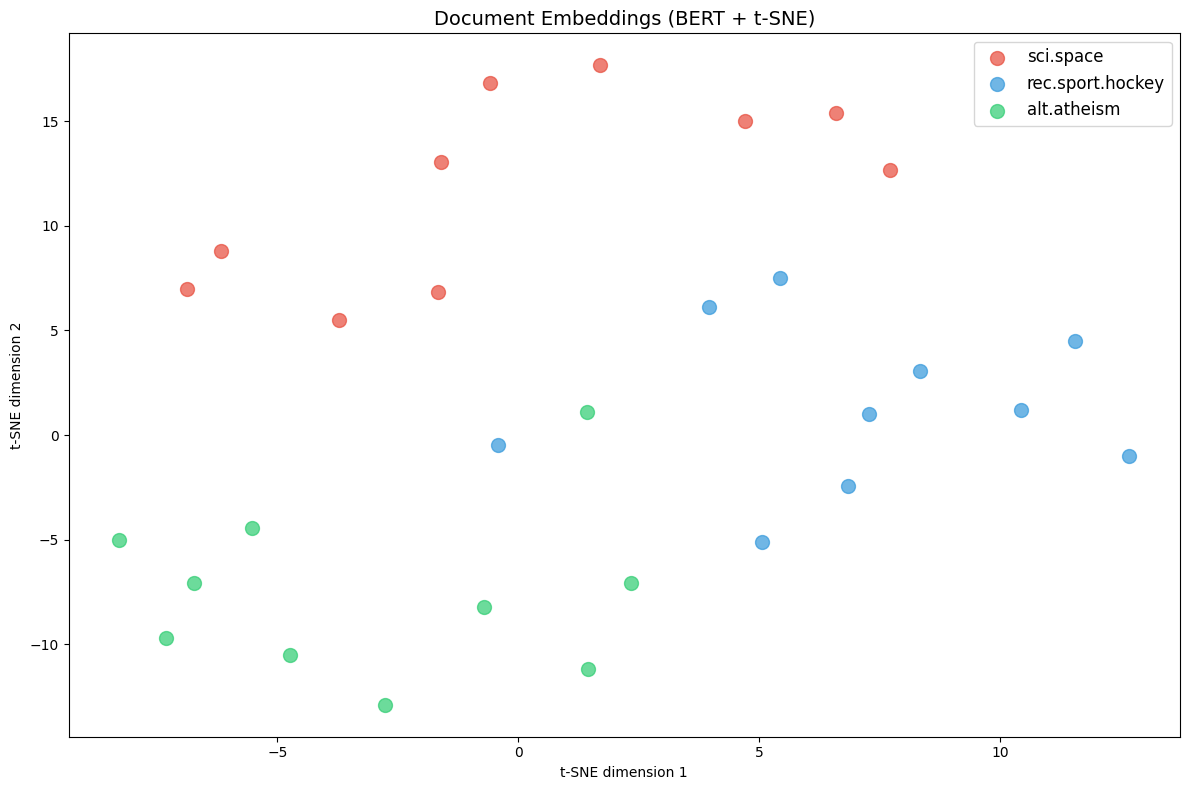

In [46]:
from sklearn.manifold import TSNE

# Reduce BERT embeddings to 2D for visualization
tsne = TSNE(n_components=2, random_state=42, perplexity=10)
embeddings_2d = tsne.fit_transform(doc_embeddings)

# Plot
plt.figure(figsize=(12, 8))

# Use the actual categories
color_list = ['#e74c3c', '#3498db', '#2ecc71']  # Red, Blue, Green

for i, category in enumerate(my_categories):
    mask = np.array([l == category for l in sampled_labels])
    plt.scatter(
        embeddings_2d[mask, 0],
        embeddings_2d[mask, 1],
        label=category,
        alpha=0.7,
        s=100,
        color=color_list[i]
    )

plt.legend(fontsize=12)
plt.title('Document Embeddings (BERT + t-SNE)', fontsize=14)
plt.xlabel('t-SNE dimension 1')
plt.ylabel('t-SNE dimension 2')
plt.tight_layout()
plt.savefig('tsne_document_embeddings.png', dpi=150)
plt.show()

### Written Question D.1 (Personal Interpretation)

Look at your t-SNE visualization:

1. **Do the categories form distinct clusters?**
2. **Are there any documents that appear in the "wrong" cluster?** What might explain this?
3. **Based on the visualization, which two categories are most similar?** Does this match your expectations from Part 1?

**YOUR ANSWER:**

1. **Do the categories form distinct clusters:**
Yes, the categories form fairly distinct clusters. The sci.space documents (red dots) are mostly grouped in the upper part of the plot. The rec.sport.hockey documents (blue dots) are clustered on the right side. The alt.atheism documents (green dots) are mostly in the lower-left area. The separation isn't perfect, but you can clearly see three different groups.

2. **Documents in the "wrong" cluster:**
Yes, there are a few documents that appear close to other categories. For example, one or two green (alt.atheism) dots appear near the red (sci.space) cluster in the middle area. This could happen because some atheism discussions mention science and the universe, which overlaps with space topics. Also, some newsgroup posts might contain off-topic discussions or replies that mix vocabulary from different categories.

3. **Which two categories are most similar:**
Based on the t-SNE plot, sci.space and alt.atheism seem the most similar because their clusters are closer together, with some overlap in the middle area. The rec.sport.hockey cluster is more separated from the other two. This makes sense because space and atheism discussions can both involve philosophical and scientific topics like the origin of the universe, while hockey is a completely different domain. This matches what I saw in the TF-IDF heatmap from Part 1, where sci.space and alt.atheism also showed slightly more cross-category similarity compared to hockey.

---

## Part E: Final Comparison and Reflection (10 min)

### Final Written Question (Comprehensive Reflection)

Based on everything you've learned in this lab:

1. **Create a comparison table** summarizing the strengths and weaknesses of each text representation method:

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|--------------|
| BoW | ... | ... | ... |
| TF-IDF | ... | ... | ... |
| Word2Vec | ... | ... | ... |
| GloVe | ... | ... | ... |
| BERT | ... | ... | ... |

2. **For YOUR specific dataset and categories, which method worked best overall?** Support your answer with specific evidence from your experiments.

3. **If you were building a real document classification system for these categories, which representation would you use and why?**

**YOUR ANSWER:**

**1. Comparison Table:**

| Method | Strengths | Weaknesses | Best Use Case |
|--------|-----------|------------|---------------|
| BoW | Simple to understand and implement, fast to compute | Ignores word order and meaning, creates very large sparse vectors | Quick text classification when you need a simple baseline |
| TF-IDF | Highlights important words by reducing common word weight, still simple and fast | Still ignores word order and meaning, no understanding of synonyms | Document search and keyword-based retrieval tasks |
| Word2Vec | Learns word meaning from context, captures relationships between words | Needs training data, single vector per word so can't handle words with multiple meanings | Finding similar words and word analogies in domain-specific text |
| GloVe | Pre-trained on huge data so works out of the box, good general word understanding | Fixed vectors that can't adapt to your specific domain, misses domain-specific jargon | General-purpose tasks when you don't have enough data to train your own model |
| BERT | Understands full sentence meaning and context, handles synonyms and paraphrasing | Slow and needs more computing power, harder to set up | Semantic search, document classification, any task where meaning matters more than keywords |

**2. Which method worked best for my dataset:**
BERT worked best overall for my three categories (sci.space, rec.sport.hockey, alt.atheism). In the semantic search test, all 5 results for my hockey query came from the correct category with good similarity scores. The t-SNE visualization showed clear separation between all three categories. The BERT heatmap also showed stronger within-category similarity compared to the TF-IDF heatmap from Part 1, where the alt.atheism block had weaker internal similarity. Word2Vec was good for finding similar words but struggled with analogies due to our small corpus size.

**3. Which representation for a real system:**
I would use BERT for a real document classification system for these categories. The main reason is that BERT understands meaning, not just word overlap. For example, a hockey post saying "he put one in the net" and another saying "he scored a goal" would be seen as similar by BERT but not by TF-IDF or BoW since they share no common words. Also, alt.atheism and sci.space can have overlapping vocabulary like "universe" and "existence", and BERT handles this better because it looks at the full sentence context. The only downside is speed, but for a classification system accuracy matters more than speed, and BERT clearly gave the best results in my experiments.

---

## Summary - Lab 3

In this lab, you learned:

**Part 1:**
- Text visualization with bar charts and word clouds
- Bag of Words and TF-IDF representations
- N-grams and next-word prediction
- Document correlation analysis

**Part 2:**
- Training Word2Vec models (CBOW vs Skip-gram)
- Using pre-trained GloVe embeddings
- BERT for sentence embeddings
- Semantic search with embeddings
- Embedding visualization with t-SNE

---

## Final Submission Checklist

- [x] All code exercises completed in Part 1 and Part 2
- [x] **All written questions answered with YOUR personal interpretation**
- [x] All visualizations saved (PNG files)
- [x] Both notebooks saved
- [ ] Pushed to Git repository
- [ ] **Repository link sent to: yoroba93@gmail.com**

### Reminder: Oral Defense

Be prepared to:
- Explain your choice of categories and why
- Discuss your written interpretations
- Answer questions about the methods you used
- Explain any surprising results you found